# Data Exploration by Jess for VenturePulse

In [254]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Prevents scientific notation
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## Basic Shape & Structure

In [255]:
df = pd.read_csv('../raw_data/investments_VC.csv', encoding='latin-1')

In [256]:
df.shape          # (rows, columns)

(54294, 39)

In [257]:
df.dtypes         # data type of each column

permalink                object
name                     object
homepage_url             object
category_list            object
 market                  object
 funding_total_usd       object
status                   object
country_code             object
state_code               object
region                   object
city                     object
funding_rounds          float64
founded_at               object
founded_month            object
founded_quarter          object
founded_year            float64
first_funding_at         object
last_funding_at          object
seed                    float64
venture                 float64
equity_crowdfunding     float64
undisclosed             float64
convertible_note        float64
debt_financing          float64
angel                   float64
grant                   float64
private_equity          float64
post_ipo_equity         float64
post_ipo_debt           float64
secondary_market        float64
product_crowdfunding    float64
round_A 

In [258]:
df.head()         # first 5 rows
df.tail()         # last 5 rows

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54293,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [259]:
df.columns.tolist()  # list of column names

['permalink',
 'name',
 'homepage_url',
 'category_list',
 ' market ',
 ' funding_total_usd ',
 'status',
 'country_code',
 'state_code',
 'region',
 'city',
 'funding_rounds',
 'founded_at',
 'founded_month',
 'founded_quarter',
 'founded_year',
 'first_funding_at',
 'last_funding_at',
 'seed',
 'venture',
 'equity_crowdfunding',
 'undisclosed',
 'convertible_note',
 'debt_financing',
 'angel',
 'grant',
 'private_equity',
 'post_ipo_equity',
 'post_ipo_debt',
 'secondary_market',
 'product_crowdfunding',
 'round_A',
 'round_B',
 'round_C',
 'round_D',
 'round_E',
 'round_F',
 'round_G',
 'round_H']

## Summary Statistics

In [260]:
df.describe()

,funding_rounds,founded_year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
count,"49,438.00","38,482.00","49,438.00","49,438.00","49,438.00","49,438.00","49,438.00","49,438.00","49,438.00","49,438.00",...,"49,438.00","49,438.00","49,438.00","49,438.00","49,438.00","49,438.00","49,438.00","49,438.00","49,438.00","49,438.00"
mean,1.70,"2,007.36","217,321.50","7,501,050.54","6,163.32","130,221.28","23,364.10","1,888,156.89","65,418.98","162,845.28",...,"38,455.92","7,074.23","1,243,955.02","1,492,891.15","1,205,355.80","737,526.06","342,468.20","169,769.19","57,670.67","14,231.97"
std,1.29,7.58,"1,056,984.82","28,471,124.16","199,904.82","2,981,403.65","1,432,045.73","138,204,566.17","658,290.79","5,612,088.00",...,"3,864,460.62","428,216.59","5,531,974.03","7,472,704.45","7,993,591.74","9,815,218.19","5,406,914.57","6,277,905.45","5,252,311.93","2,716,865.29"
min,1.00,"1,902.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,"2,006.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,1.00,"2,010.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,2.00,"2,012.00","25,000.00","5,000,000.00",0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,18.00,"2,014.00","130,000,000.00","2,351,000,000.00","25,000,000.00","292,432,833.00","300,000,000.00","30,079,503,000.00","63,590,263.00","750,500,000.00",...,"680,611,554.00","72,000,000.00","319,000,000.00","542,000,000.00","490,000,000.00","1,200,000,000.00","400,000,000.00","1,060,000,000.00","1,000,000,000.00","600,000,000.00"


In [261]:
df.nunique()

permalink               49436
name                    49350
homepage_url            45850
category_list           16675
 market                   753
 funding_total_usd      14617
status                      3
country_code              115
state_code                 61
region                   1089
city                     4188
funding_rounds             17
founded_at               3369
founded_month             420
founded_quarter           218
founded_year              103
first_funding_at         3914
last_funding_at          3657
seed                     3337
venture                  9300
equity_crowdfunding       252
undisclosed               687
convertible_note          299
debt_financing           1872
angel                     999
grant                     532
private_equity            847
post_ipo_equity           239
post_ipo_debt              57
secondary_market           20
product_crowdfunding      176
round_A                  2035
round_B                  1269
round_C   

In [262]:
df['venture'].head(20)          # first 20 values

0            0.00
1    4,000,000.00
2            0.00
3            0.00
4            0.00
5    7,000,000.00
6            0.00
7    2,000,000.00
8            0.00
9            0.00
10           0.00
11           0.00
12           0.00
13           0.00
14           0.00
15   4,000,000.00
16           0.00
17           0.00
18           0.00
19           0.00
Name: venture, dtype: float64

## Missing Values

In [263]:
df.isna().sum()

permalink                4856
name                     4857
homepage_url             8305
category_list            8817
 market                  8824
 funding_total_usd       4856
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds           4856
founded_at              15740
founded_month           15812
founded_quarter         15812
founded_year            15812
first_funding_at         4856
last_funding_at          4856
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_A                  4856
round_B                  4856
round_C   

In [264]:
df.isna().mean().mul(100).round(2).astype(str) + '%'

permalink                8.94%
name                     8.95%
homepage_url             15.3%
category_list           16.24%
 market                 16.25%
 funding_total_usd       8.94%
status                  11.36%
country_code            18.66%
state_code              44.45%
region                  18.66%
city                    20.21%
funding_rounds           8.94%
founded_at              28.99%
founded_month           29.12%
founded_quarter         29.12%
founded_year            29.12%
first_funding_at         8.94%
last_funding_at          8.94%
seed                     8.94%
venture                  8.94%
equity_crowdfunding      8.94%
undisclosed              8.94%
convertible_note         8.94%
debt_financing           8.94%
angel                    8.94%
grant                    8.94%
private_equity           8.94%
post_ipo_equity          8.94%
post_ipo_debt            8.94%
secondary_market         8.94%
product_crowdfunding     8.94%
round_A                  8.94%
round_B 

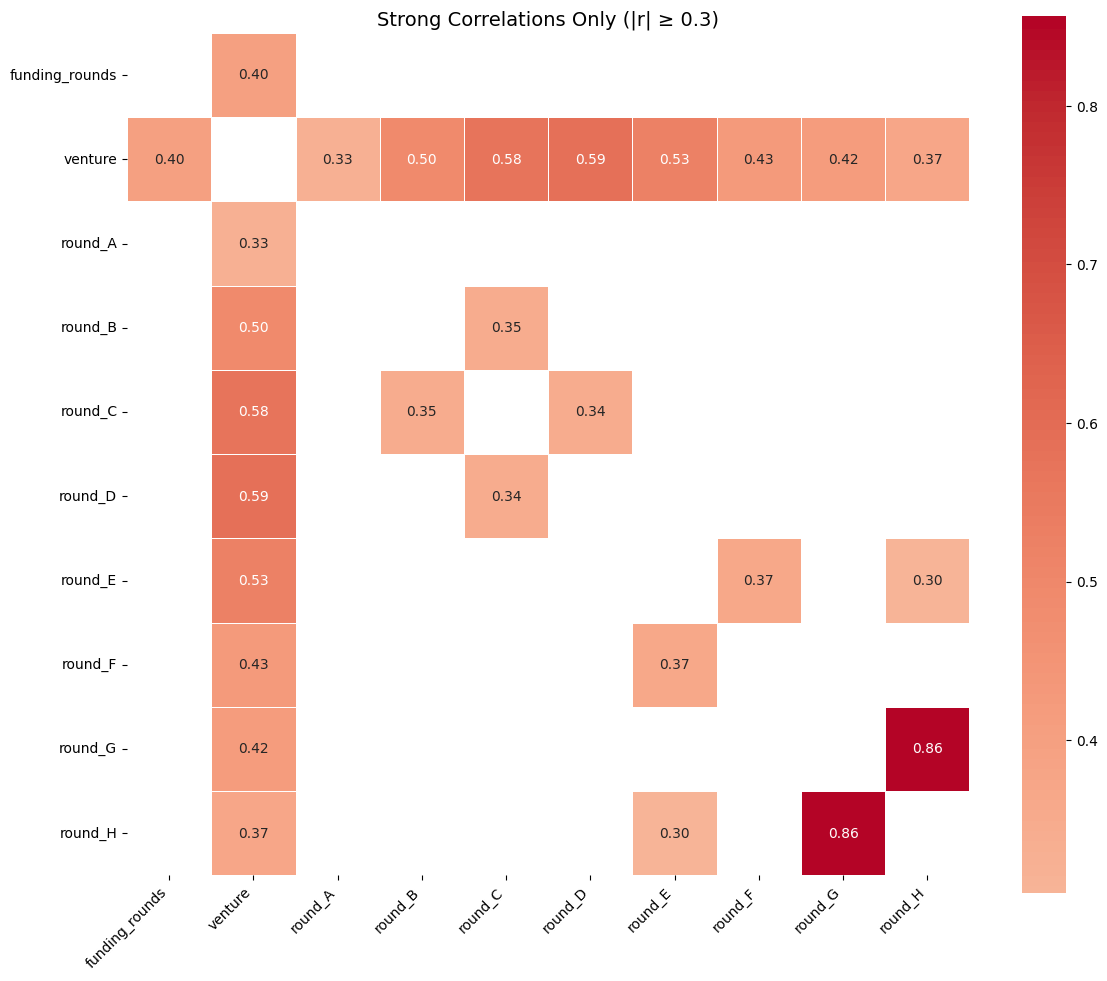

In [265]:
corr = df.corr(numeric_only=True)

# Keep only correlations above a threshold (e.g. 0.3), excluding self-correlation
threshold = 0.3
strong_corr = corr[(corr.abs() >= threshold) & (corr != 1.0)]

# Drop rows/cols that are all NaN after filtering
strong_corr = strong_corr.dropna(how='all').dropna(axis=1, how='all')

plt.figure(figsize=(12, 10))
sns.heatmap(
    strong_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Strong Correlations Only (|r| ≥ 0.3)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Prep for Data Cleaning

In [266]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': df.isna().mean().mul(100).round(2),
    'dtype': df.dtypes
}).sort_values('missing_pct', ascending=False)

print(missing)

                      missing_count  missing_pct    dtype
state_code                    24133        44.45   object
founded_month                 15812        29.12   object
founded_year                  15812        29.12  float64
founded_quarter               15812        29.12   object
founded_at                    15740        28.99   object
city                          10972        20.21   object
country_code                  10129        18.66   object
region                        10129        18.66   object
 market                        8824        16.25   object
category_list                  8817        16.24   object
homepage_url                   8305        15.30   object
status                         6170        11.36   object
name                           4857         8.95   object
post_ipo_debt                  4856         8.94  float64
secondary_market               4856         8.94  float64
product_crowdfunding           4856         8.94  float64
round_A       

In [267]:
# Z-score method — flags values more than 3 std deviations from mean
numeric_cols = df.select_dtypes(include='number').columns
z_scores = df[numeric_cols].apply(stats.zscore, nan_policy='omit').abs()

outlier_counts = (z_scores > 3).sum().sort_values(ascending=False)
print(outlier_counts)

funding_rounds          1156
round_B                  707
round_C                  667
founded_year             623
round_A                  594
venture                  580
seed                     405
round_D                  331
private_equity           321
round_E                  301
angel                    298
undisclosed              158
round_F                  102
equity_crowdfunding       87
grant                     73
post_ipo_equity           63
product_crowdfunding      50
convertible_note          39
debt_financing            32
post_ipo_debt             22
round_G                   22
secondary_market          11
round_H                    3
dtype: int64


In [268]:
# Negative values in columns that should always be positive
for col in ['venture', 'seed', 'round_A', 'round_B', 'funding_rounds']:
    neg = (df[col] < 0).sum()
    if neg > 0:
        print(f"{col}: {neg} negative values")

In [269]:
# Founded year sanity check
print(df['founded_year'].value_counts().sort_index().head(10))  # very old dates?
print(df['founded_year'].value_counts().sort_index().tail(10))  # future dates?

founded_year
1,902.00    2
1,903.00    1
1,905.00    1
1,906.00    5
1,907.00    1
1,908.00    1
1,910.00    2
1,911.00    2
1,912.00    6
1,913.00    2
Name: count, dtype: int64
founded_year
2,005.00    1418
2,006.00    1807
2,007.00    2331
2,008.00    2348
2,009.00    2979
2,010.00    3773
2,011.00    4905
2,012.00    5211
2,013.00    4044
2,014.00    1469
Name: count, dtype: int64


In [270]:
# Companies with 0 funding rounds but venture money > 0 (contradiction)
df[(df['funding_rounds'] == 0) & (df['venture'] > 0)][['name', 'funding_rounds', 'venture']]

,name,funding_rounds,venture


In [271]:
# Companies with round_B > 0 but round_A == 0 (skipped a round?)
df[(df['round_B'] > 0) & (df['round_A'] == 0)][['name', 'round_A', 'round_B']]

,name,round_A,round_B
5,.Club Domains,0.00,"7,000,000.00"
23,1006.tv,0.00,"10,000,000.00"
37,117go,0.00,"20,000,000.00"
65,19pay,0.00,"6,230,000.00"
119,248 SolidState,0.00,"500,000.00"
...,...,...,...
49194,Zipcar,0.00,"4,704,370.00"
49215,Zipscene,0.00,"8,750,000.00"
49311,ZoomSystems,0.00,"12,000,000.00"
49318,Zoopla,0.00,"5,440,000.00"


In [272]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(f"  Unique values: {df[col].nunique()}")
    print(f"  Sample values: {df[col].dropna().unique()[:10]}")
    print(f"  Whitespace/case issues: {df[col].str.strip().ne(df[col]).sum()} rows")


--- permalink ---
  Unique values: 49436
  Sample values: ['/organization/waywire' '/organization/tv-communications'
 '/organization/rock-your-paper' '/organization/in-touch-network'
 '/organization/r-ranch-and-mine' '/organization/club-domains'
 '/organization/fox-networks' '/organization/0-6-com'
 '/organization/004-technologies' '/organization/01games-technology']
  Whitespace/case issues: 4856 rows

--- name ---
  Unique values: 49350
  Sample values: ['#waywire' '&TV Communications' "'Rock' Your Paper" '(In)Touch Network'
 '-R- Ranch and Mine' '.Club Domains' '.Fox Networks' '0-6.com'
 '004 Technologies' '01Games Technology']
  Whitespace/case issues: 4857 rows

--- homepage_url ---
  Unique values: 45850
  Sample values: ['http://www.waywire.com' 'http://enjoyandtv.com'
 'http://www.rockyourpaper.org' 'http://www.InTouchNetwork.com'
 'http://nic.club/' 'http://www.dotfox.com' 'http://www.0-6.com'
 'http://004gmbh.de/en/004-interact' 'http://www.01games.hk/'
 'http://www.123listo

In [273]:
# Calculate % of missing values for each row
row_missing_pct = df.isna().mean(axis=1).mul(100).round(2)

# Summary of that distribution
print(row_missing_pct.describe())

count   54,294.00
mean        13.31
std         27.85
min          0.00
25%          0.00
50%          2.56
75%         10.26
max        100.00
dtype: float64


In [274]:
# How many rows fall into each "missingness bucket"
buckets = pd.cut(row_missing_pct, bins=[0, 25, 50, 75, 100])
print(buckets.value_counts().sort_index())

(0, 25]      26823
(25, 50]       775
(50, 75]         0
(75, 100]     4856
Name: count, dtype: int64


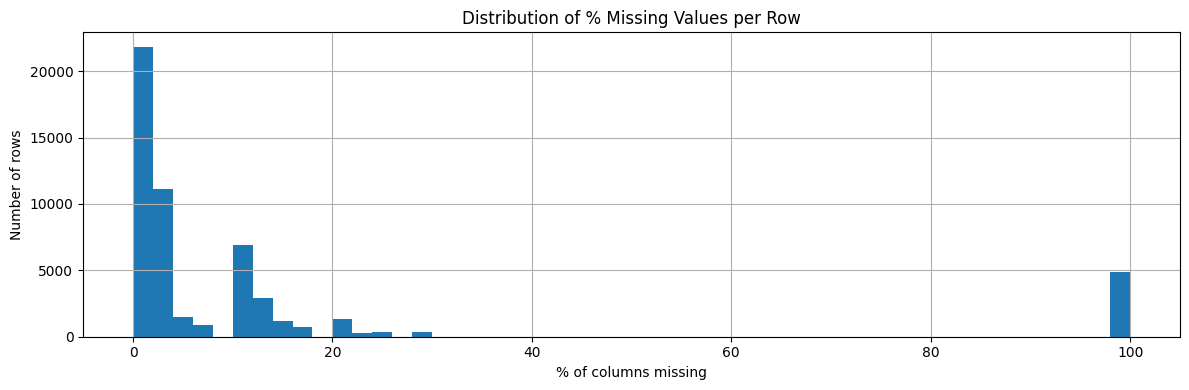

In [275]:
plt.figure(figsize=(12, 4))
row_missing_pct.hist(bins=50)
plt.title('Distribution of % Missing Values per Row')
plt.xlabel('% of columns missing')
plt.ylabel('Number of rows')
plt.tight_layout()
plt.show()

In [276]:
threshold = 50  # rows missing more than 50% of their values

sparse_rows = df[row_missing_pct > threshold]
print(f"Rows with >{threshold}% missing: {len(sparse_rows)} ({len(sparse_rows)/len(df)*100:.1f}% of dataset)")
sparse_rows.head(10)


Rows with >50% missing: 4856 (8.9% of dataset)


,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
49438,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49447,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [277]:
# Full picture of missing data
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': df.isna().mean().mul(100).round(2),
    'dtype': df.dtypes
}).sort_values('missing_pct', ascending=False)

row_missing_pct = df.isna().mean(axis=1).mul(100)

In [278]:
print("\n=== DATA QUALITY SUMMARY ===")
print(f"Shape: {df.shape}")

print(f"Rows with >50% missing: {(row_missing_pct > 50).sum()}")

print(f"\nColumns with any missing:")
print(missing[missing['missing_count'] > 0])


=== DATA QUALITY SUMMARY ===
Shape: (54294, 39)
Rows with >50% missing: 4856

Columns with any missing:
                      missing_count  missing_pct    dtype
state_code                    24133        44.45   object
founded_month                 15812        29.12   object
founded_year                  15812        29.12  float64
founded_quarter               15812        29.12   object
founded_at                    15740        28.99   object
city                          10972        20.21   object
country_code                  10129        18.66   object
region                        10129        18.66   object
 market                        8824        16.25   object
category_list                  8817        16.24   object
homepage_url                   8305        15.30   object
status                         6170        11.36   object
name                           4857         8.95   object
post_ipo_debt                  4856         8.94  float64
secondary_market         